# Exploratory Data Analysis (EDA)

## Objective
The goal of this notebook is to understand the distribution of the data,
discover relationships between variables, identify important features,
detect outliers, and generate business insights before model training.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
df = pd.read_csv("../data/processed/cleaned_used_cars.csv")

In [5]:
df.shape

(37813, 72)

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 37813 entries, 0 to 37812
Data columns (total 72 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   position               37813 non-null  int64  
 1   model_year             37813 non-null  int64  
 2   body_type              37813 non-null  str    
 3   transmission           37813 non-null  str    
 4   fuel_type              37813 non-null  str    
 5   full_vehicle_name      37813 non-null  str    
 6   brand                  37813 non-null  str    
 7   model                  37813 non-null  str    
 8   vehicle_name           37813 non-null  str    
 9   centralVariantId       37813 non-null  int64  
 10  variantName            37813 non-null  str    
 11  city_x                 37813 non-null  str    
 12  price                  37813 non-null  int64  
 13  discountValue          37813 non-null  int64  
 14  msp                    37813 non-null  int64  
 15  utype        

In [7]:
df.head()

,position,model_year,body_type,transmission,fuel_type,full_vehicle_name,brand,model,vehicle_name,centralVariantId,...,body_type_new,owner_type_new,variant_name,price_segment,brand_new,variant_new,exterior_color,owner_type,price_segment_new,Fuel Suppy System
0,1,2016,Hatchback,Manual,CNG,Maruti Wagon R LXI CNG,Maruti,Maruti Wagon R,Maruti Wagon R LXI CNG,4312,...,Hatchback cars,first,maruti wagon r lxi cng,2lakh-5lakh,maruti,maruti wagon r lxi cng,Silver,first,2lakh-5lakh,MPFI
1,2,2015,Hatchback,Manual,CNG,Maruti Celerio Green VXI,Maruti,Maruti Celerio,Maruti Celerio Green VXI,3984,...,Hatchback cars,first,maruti celerio green vxi,2lakh-5lakh,maruti,maruti celerio green vxi,Grey,first,2lakh-5lakh,Intelligent-Gas Port Injection
2,3,2015,Sedan,Manual,CNG,Honda Amaze S Plus i-VTEC,Honda,Honda Amaze,Honda Amaze S Plus i-VTEC,1177,...,Sedan cars,second,honda amaze s plus i-vtec,2lakh-5lakh,honda,honda amaze s plus i-vtec,Silver,second,2lakh-5lakh,MPFI
3,4,2013,Hatchback,Manual,CNG,Maruti Wagon R LXI CNG,Maruti,Maruti Wagon R,Maruti Wagon R LXI CNG,4351,...,Hatchback cars,second,maruti wagon r lxi cng,2lakh-5lakh,maruti,maruti wagon r lxi cng,Silver,second,2lakh-5lakh,MPFI
4,5,2022,MUV,Manual,CNG,Maruti Ertiga VXI CNG,Maruti,Maruti Ertiga,Maruti Ertiga VXI CNG,8957,...,MUV cars,first,maruti ertiga vxi cng,10+lakh,maruti,maruti ertiga vxi cng,White,first,10+lakh,MPFI


In [8]:
df.describe()

,position,model_year,centralVariantId,price,discountValue,msp,Displacement,Max Power,Max Torque,No of Cylinder,Values per Cylinder,Length,Width,Height,Wheel Base,Seating Capacity,No Door Numbers,km_driven,used_carid
count,37813.000000,37813.000000,37813.000000,3.781300e+04,37813.000000,3.781300e+04,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,37813.000000,3.781300e+04,3.781300e+04
mean,12.786528,2015.569460,4244.421786,7.854508e+05,73.281702,5.426705e+01,1438.369767,102.667226,178.565484,3.820088,3.894639,4073.186655,1709.861556,1562.437707,2502.459339,5.236612,4.664480,6.240901e+04,3.350111e+06
std,4.538552,3.779097,2456.179185,1.132718e+06,2805.783272,7.477564e+03,470.289774,42.667988,106.060102,0.540516,0.477025,555.307512,207.482666,188.306065,361.008026,0.722096,0.496371,5.847222e+04,4.822133e+04
min,1.000000,1983.000000,3.000000,1.196300e+04,0.000000,0.000000e+00,0.000000,10.800000,4.800000,1.000000,1.000000,3.000000,1.000000,1.000000,2.000000,0.000000,2.000000,1.010000e+02,2.123741e+06
25%,9.000000,2013.000000,1689.000000,3.200000e+05,0.000000,0.000000e+00,1197.000000,75.000000,110.000000,4.000000,4.000000,3780.000000,1677.000000,1495.000000,2425.000000,5.000000,4.000000,3.173900e+04,3.323256e+06
50%,13.000000,2016.000000,4191.000000,5.250000e+05,0.000000,0.000000e+00,1248.000000,88.500000,145.000000,4.000000,4.000000,3995.000000,1710.000000,1530.000000,2520.000000,5.000000,5.000000,5.672600e+04,3.366215e+06
75%,17.000000,2018.000000,6373.000000,8.550000e+05,0.000000,0.000000e+00,1582.000000,118.350000,220.000000,4.000000,4.000000,4430.000000,1790.000000,1640.000000,2636.000000,5.000000,5.000000,8.331000e+04,3.384768e+06
max,20.000000,2023.000000,9670.000000,9.551953e+07,200000.000000,1.093000e+06,6749.000000,769.310000,900.000000,16.000000,48.000000,5982.000000,2236.000000,2075.000000,3772.000000,14.000000,6.000000,6.300000e+06,3.399050e+06


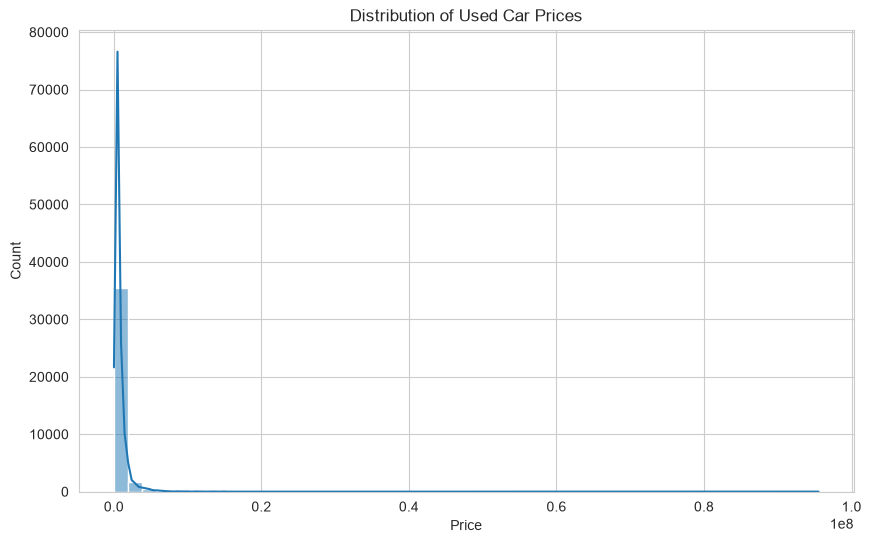

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="price",
    bins=50,
    kde=True
)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [10]:
df["price"].describe()

count    3.781300e+04
mean     7.854508e+05
std      1.132718e+06
min      1.196300e+04
25%      3.200000e+05
50%      5.250000e+05
75%      8.550000e+05
max      9.551953e+07
Name: price, dtype: float64

In [11]:
df["price"].skew()

np.float64(22.230988655489238)

### Insight 1: Distribution of Used Car Prices

- The distribution of used car prices is highly positively skewed.
- Most used cars are priced below ₹10 lakh.
- A small number of luxury vehicles create a long right tail.
- The mean price (₹7.85 lakh) is considerably higher than the median (₹5.25 lakh), confirming the effect of expensive outliers.
- The target variable has a skewness of 22.23, indicating an extremely right-skewed distribution.